In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_parquet("cleaned_data.parquet")

### Customer Overview

Customers ages start at late teen and keep growing until around when people have children, when many parents focus more on child and family welfare than keeping up with the lastest fashion.

As the children hit 

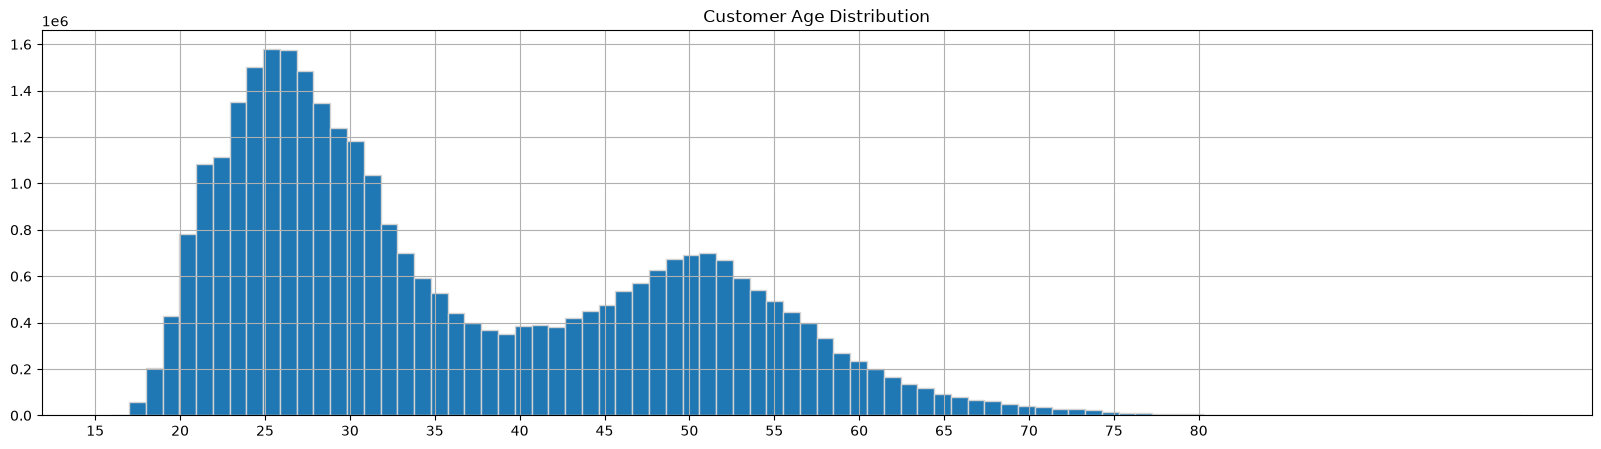

In [2]:
fig, ax = plt.subplots()

df['age'].hist(figsize=(20, 5), bins=84, edgecolor='lightgray')

ax.set_xticks(np.arange(15, 85, 5))

plt.title('Customer Age Distribution')

plt.show()

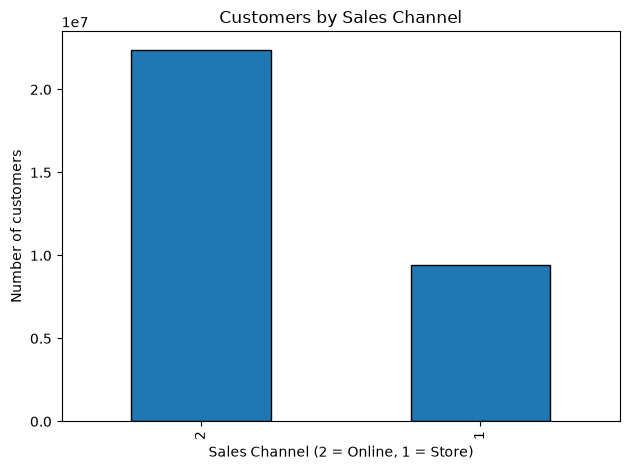

In [3]:
df['sales_channel_id'].value_counts().plot.bar( edgecolor='black')
plt.title('Customers by Sales Channel')
plt.xlabel('Sales Channel (2 = Online, 1 = Store)')
plt.ylabel('Number of customers')
plt.tight_layout()
plt.show()

### Transaction Overview

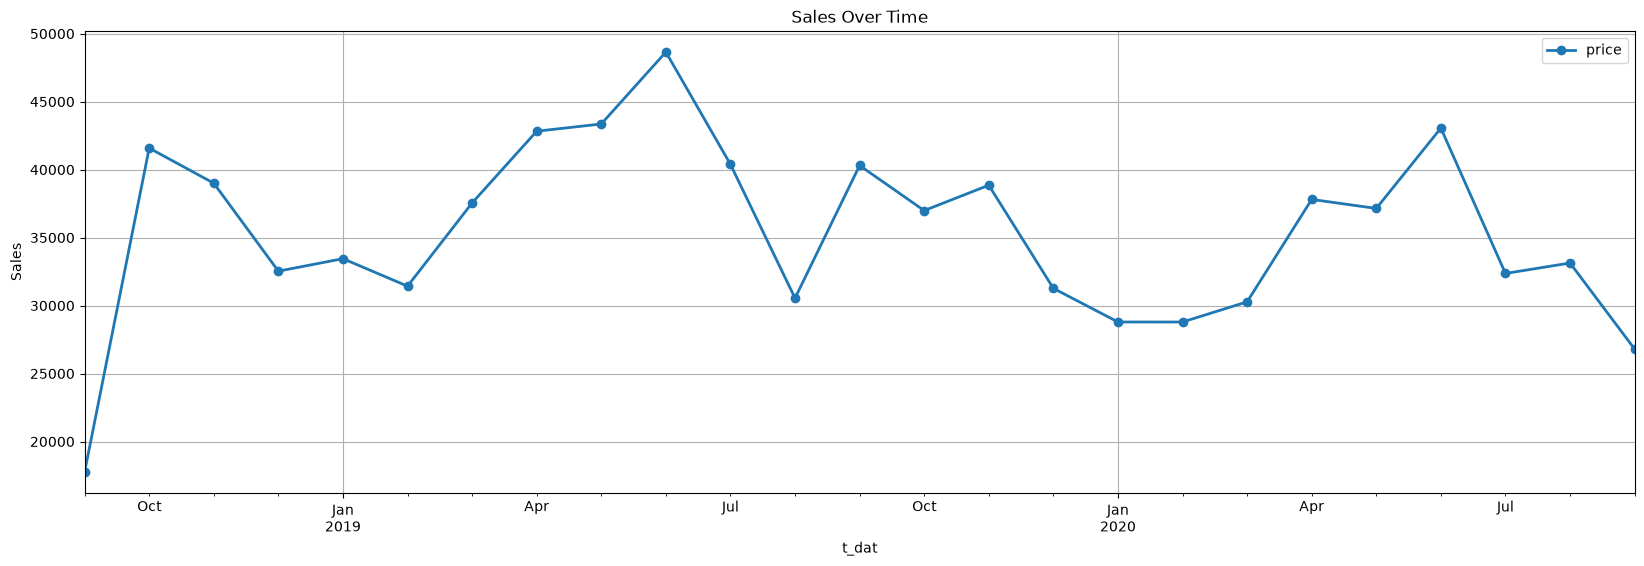

In [4]:
df['t_dat'] = pd.to_datetime(df['t_dat'])

monthly_sales = df.groupby(pd.Grouper(key='t_dat', freq='ME'))['price'].sum().reset_index()

monthly_sales = monthly_sales.set_index('t_dat')

monthly_sales.plot(kind='line', figsize=(20, 6), marker='o', linewidth=2)

plt.title('Sales Over Time')
plt.ylabel('Sales')
plt.grid(True)

plt.show()

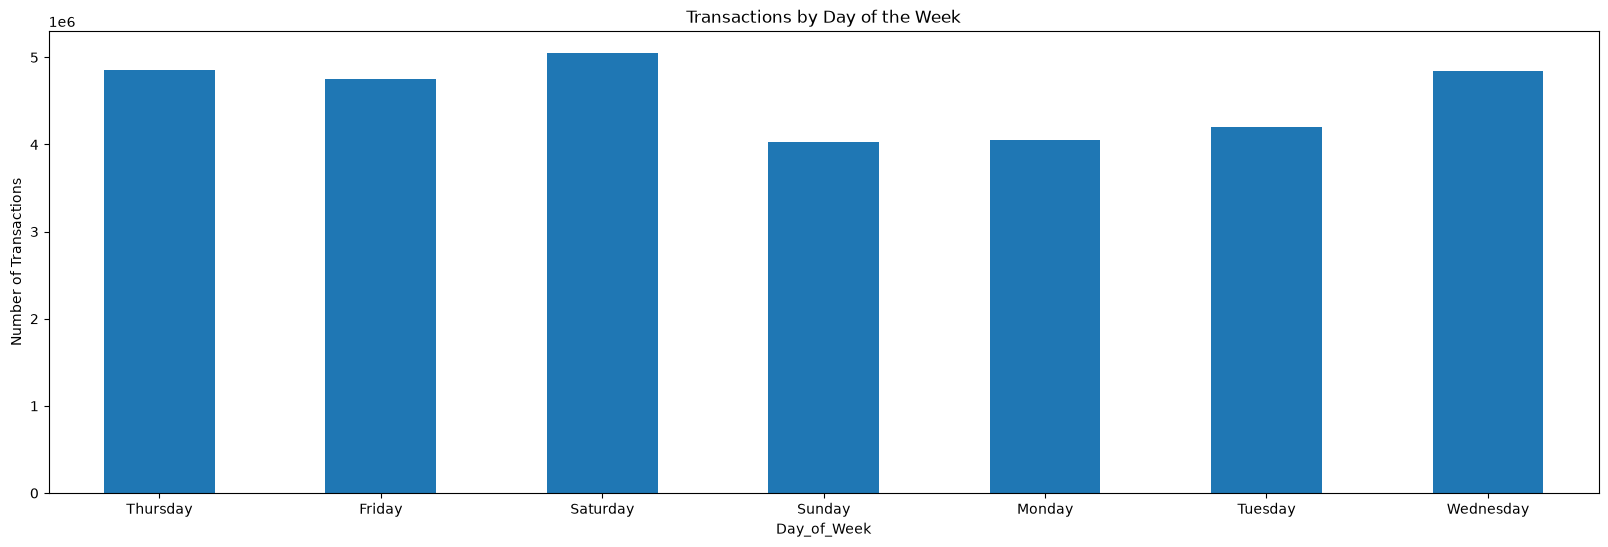

In [5]:

df['Day_of_Week'] = df['t_dat'].dt.day_name()

day_counts = df.groupby('Day_of_Week', sort=False)['t_dat'].count()

day_counts.plot(kind='bar', figsize=(20, 6))

plt.title('Transactions by Day of the Week')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=0)
plt.show()

count    3.178832e+07
mean     2.782927e-02
std      1.918113e-02
min      1.694915e-05
25%      1.581356e-02
50%      2.540678e-02
75%      3.388136e-02
max      5.915254e-01
Name: price, dtype: float64


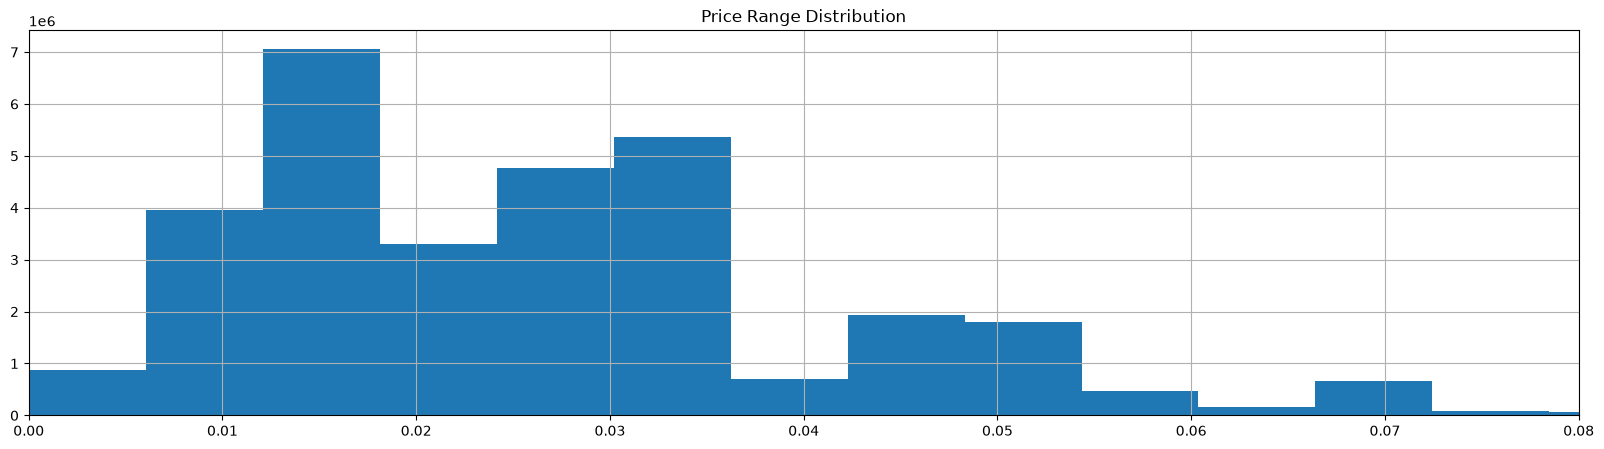

In [6]:
print(df['price'].describe())

#IQR (Q3 - Q1): 0.03388136 - 0.01581356 = 0.0180678
# Lower Bound (Q1 - 1.5 × IQR): -0.011288
# Upper Bound (Q3 + 1.5 × IQR): 0.0609832. 
# 
# There are no lower outliers. The absolute minimum value (0.0000169) sits well above the negative lower bound.
# 
# It is heavily skewed upward. The maximum value of 0.5915254 is nearly 10 times higher than the upper threshold limit (0.060983).
# 
# Furthermore, the 75th percentile is only 0.0338, which means at least 75% of the 31.7-million-row dataset is packed below that number. 
# 
# The jump from 0.0338 to a maximum of 0.5915 signals a long, sparse right-hand tail pulling the mean higher than your 50% median.

fig, ax = plt.subplots()

df['price'].hist(figsize=(20,5), bins=98)

plt.title('Price Range Distribution')
plt.xlim(0, 0.08) # exclude the extreme outliers to better visualize the distribution of the majority of the data
plt.show()

sales_channel_id
2    75.619306
1    24.380694
Name: price, dtype: float64


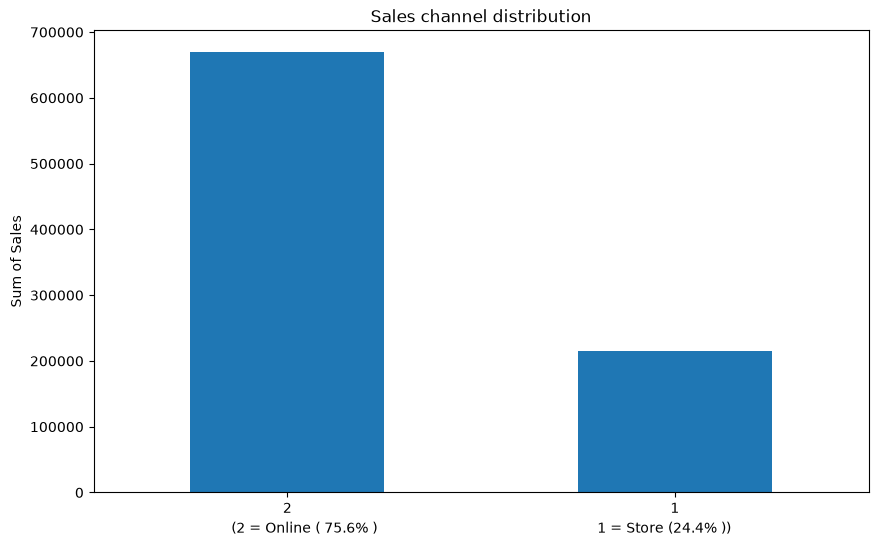

In [7]:
channel_sales = df.groupby('sales_channel_id', sort=False)['price'].sum()

print((channel_sales / df['price'].sum()) * 100)

sum_of_sales = df.groupby('sales_channel_id', sort=False)['price'].sum()

sum_of_sales.plot(kind='bar', figsize=(10, 6))

plt.title('Sales channel distribution')
plt.ylabel('Sum of Sales')
plt.xlabel('(2 = Online ( 75.6% )                                                       1 = Store (24.4% ))')
plt.xticks(rotation=0)
plt.show()


### Product Overview

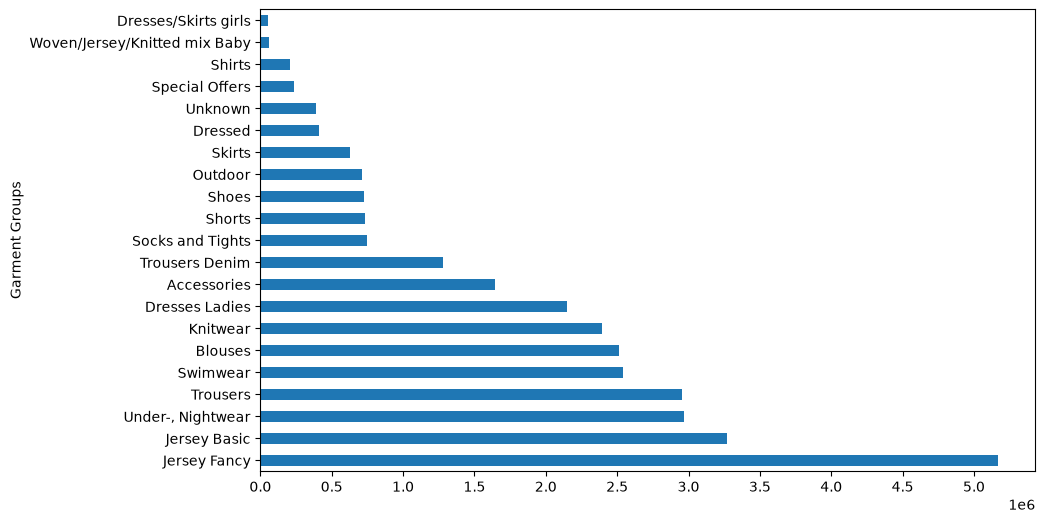

In [8]:
fig, ax = plt.subplots()
df['garment_group_name'].value_counts().plot(kind='barh', figsize=(10, 6))
plt.ylabel('Garment Groups')
ax.set_xticks(np.arange(0, 5500000, 500000))

plt.show()


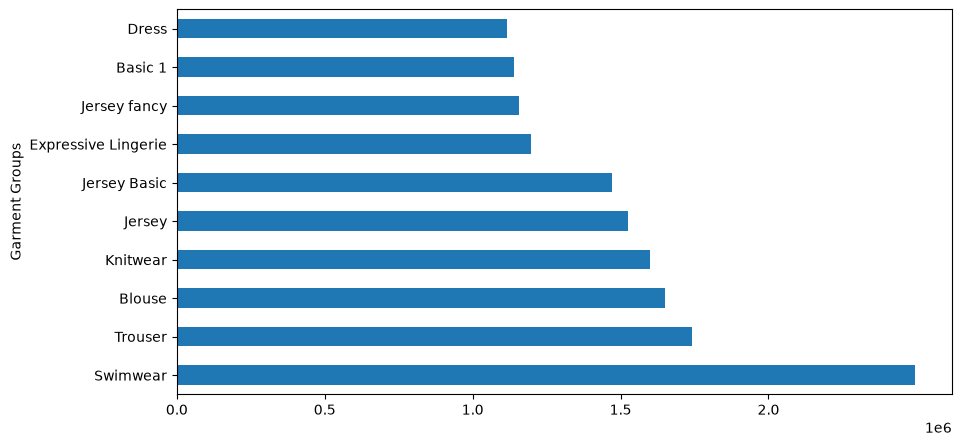

In [9]:
fig, ax = plt.subplots()
df['department_name'].value_counts().head(10).plot(kind='barh', figsize=(10, 5))
plt.ylabel('Garment Groups')
ax.set_xticks(np.arange(0, 2500000, 500000))

plt.show()

In [10]:
df['product_type_name'].value_counts().head(10).reset_index()


,product_type_name,count
0,Trousers,4217017
1,Dress,3238428
2,Sweater,2783274
3,T-shirt,2203750
4,Top,1583408
5,Blouse,1504868
6,Vest top,1414101
7,Bra,1335233
8,Shorts,1152513
9,Bikini top,1126202


### Customer Purchasing Behavior Overview

In [11]:
#there are 1,362,281 customers

purchase_counts = df['customer_id'].value_counts()

customers_by_purchase_count = purchase_counts.value_counts()

print(customers_by_purchase_count.head(20))
print(customers_by_purchase_count.tail(20))

count
1     131514
2     127441
3      95686
4      82082
5      64635
6      56820
7      47385
8      43047
9      37627
10     34262
11     30337
12     27985
13     25114
14     23585
15     21685
16     20158
17     19070
18     17969
19     16618
20     16084
Name: count, dtype: int64
count
594    1
591    1
588    1
585    1
573    1
572    1
571    1
570    1
568    1
567    1
561    1
557    1
546    1
545    1
537    1
534    1
531    1
528    1
526    1
525    1
Name: count, dtype: int64


customer_id    00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...
price                                                   0.000763
dtype: object customer_id    ffffd9ac14e89946416d80e791d064701994755c3ab686...
price                                                  57.676407
dtype: object


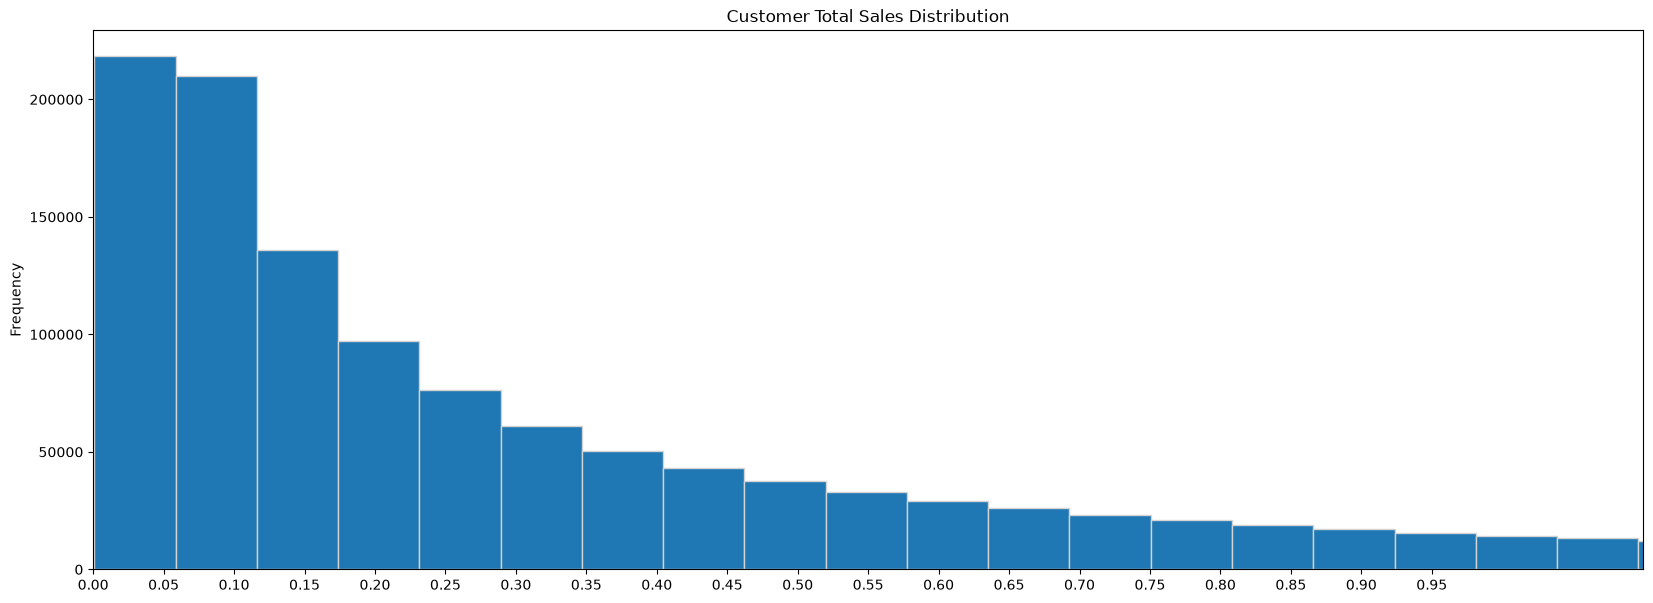

In [12]:
customer_totals = df.groupby('customer_id', as_index=False)['price'].sum()
print (customer_totals.min(), customer_totals.max())
# print(customer_totals.head(50))

fig, ax = plt.subplots()

customer_totals['price'].plot(kind='hist', bins=1000, title='Customer Total Sales Distribution', figsize=(20, 7), edgecolor='lightgray')

# df['customer_totals'].hist(figsize=(20, 5), bins=84, edgecolor='lightgray')

ax.set_xticks(np.arange(0,1, .05))
plt.xlim(0, 1.1) # exclude the extreme outliers to better visualize the distribution of the majority of the data


plt.show()


min price    1
dtype: int64

max price    1895
dtype: int64

unique price    747
dtype: int64


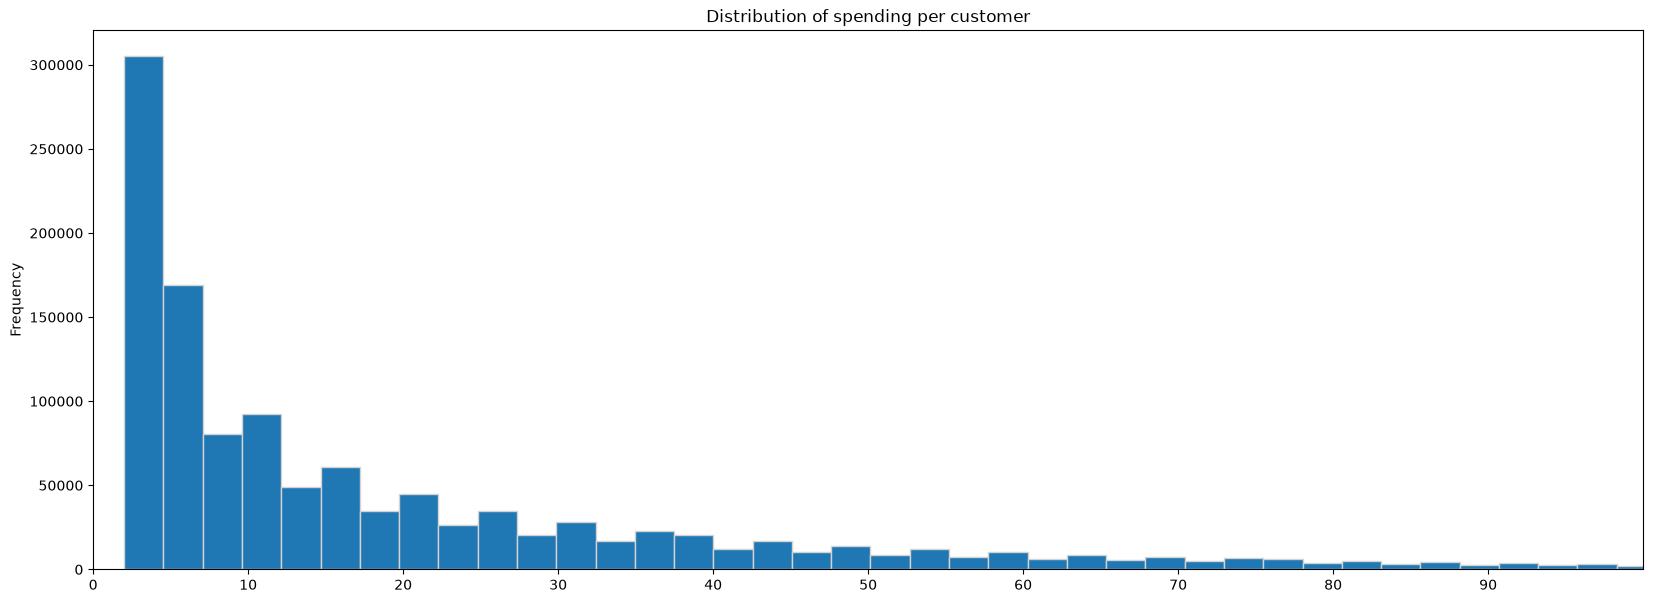

In [13]:
number_of_purchases = df.groupby('customer_id', as_index=False)['price'].count().drop(columns='customer_id')    
print ('\nmin', number_of_purchases.min())
print ("\nmax", number_of_purchases.max())
print('\nunique', number_of_purchases.nunique())

number_of_purchases = number_of_purchases.loc[number_of_purchases['price'] > 1]

# print('\ngreater than 1', number_of_purchases)
fig, ax = plt.subplots()

number_of_purchases['price'].plot(kind='hist', bins=747, title='Distribution of spending per customer', figsize=(20, 7), edgecolor='lightgray')


ax.set_xticks(np.arange(0, 100, 10))
plt.xlim(0, 100) # exclude the extreme outliers to better visualize the distribution of the majority of the data


plt.show()

In [14]:

purchases = df[['customer_id', 'price', 't_dat']]

df['t_dat'] = pd.to_datetime(df['t_dat'])

filtered_df = df.groupby('customer_id').filter(lambda x: len(x) > 1)

result = (
    filtered_df.groupby('customer_id')['t_dat']
    .agg(
        min_t_dat='min',
        max_t_dat='max',
        days_active=lambda x: (x.max() - x.min()).dt.days
        if hasattr(x.max() - x.min(), 'dt')
        else (x.max() - x.min()).days,
    )
    .reset_index()
)



0
733
281
316459


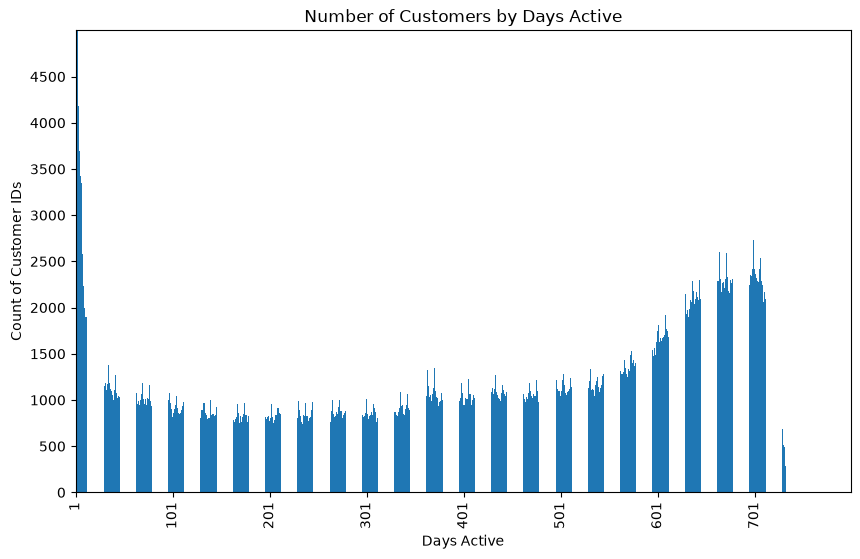

In [15]:
final_counts = (
    result.groupby('days_active')['customer_id']
    .count()
    .reset_index(name='count_of_ids')
)

print(final_counts["days_active"].min())
print(final_counts["days_active"].max())
print(final_counts["count_of_ids"].min())
print(final_counts["count_of_ids"].max())

final_counts = final_counts.loc[final_counts['count_of_ids'] > 0]


final_counts.plot(
    kind='bar',
    x='days_active',
    y='count_of_ids',
    legend=False,
    figsize=(10, 6)
)
plt.xlim(1, 800)
plt.ylim(0, 5000)
plt.title('Number of Customers by Days Active')
plt.xlabel('Days Active')
plt.ylabel('Count of Customer IDs')
plt.xticks(np.arange(1, 800, 100))
plt.yticks(np.arange(0, 5000, 500))

plt.show()

In [33]:
transactions = df[["customer_id", "t_dat"]].copy()

transactions["t_dat"] = pd.to_datetime(transactions["t_dat"])



In [ ]:
# keep one row per customer per shopping day
purchase_days = (
    transactions
    .drop_duplicates()
    .sort_values(["customer_id", "t_dat"])
    .copy()
)


In [ ]:

# calculate days between shopping days
days_between_purchases = purchase_days["days_between_purchases"] = (
    purchase_days
        .groupby("customer_id")["t_dat"]
        .diff()
        .dt.days
)

In [39]:
desc = purchase_days["days_between_purchases"].describe()

print(desc.to_string(float_format=lambda x: f"{x:.2f}"))

count   7717898.00
mean         48.26
std          71.68
min           1.00
25%           7.00
50%          22.00
75%          58.00
max         731.00


In [41]:
purchase_days["days_between_purchases"].quantile(
    [0.25, 0.50, 0.75, 0.90, 0.95]
)

0.25      7.0
0.50     22.0
0.75     58.0
0.90    124.0
0.95    187.0
Name: days_between_purchases, dtype: float64

<Axes: >

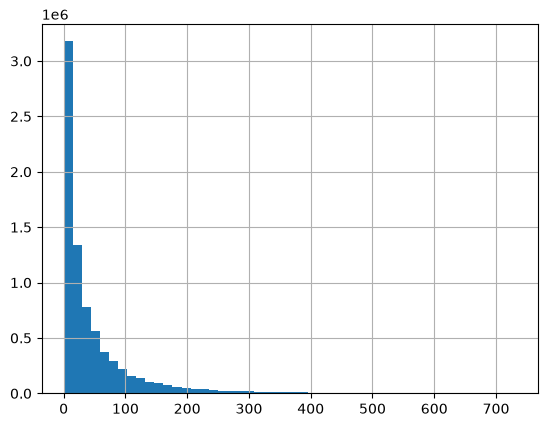

In [42]:
purchase_days["days_between_purchases"].hist(bins=50)